In [1]:
#import the libraries
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
#load the dataset
df= pd.read_csv("netflix_titles.csv")
#clean the dataset
df=df.dropna(subset=['type','release_year','rating','country','duration'])
type_counts = df['type'].value_counts() 

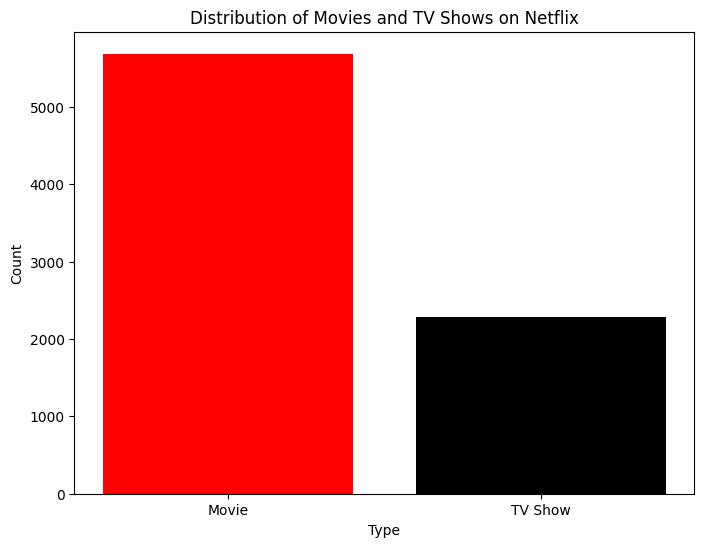

In [15]:
#plotting the bar chart
plt.figure(figsize=(8,6))
plt.bar(type_counts.index, type_counts.values, color=['red', 'black'])
plt.title('Distribution of Movies and TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

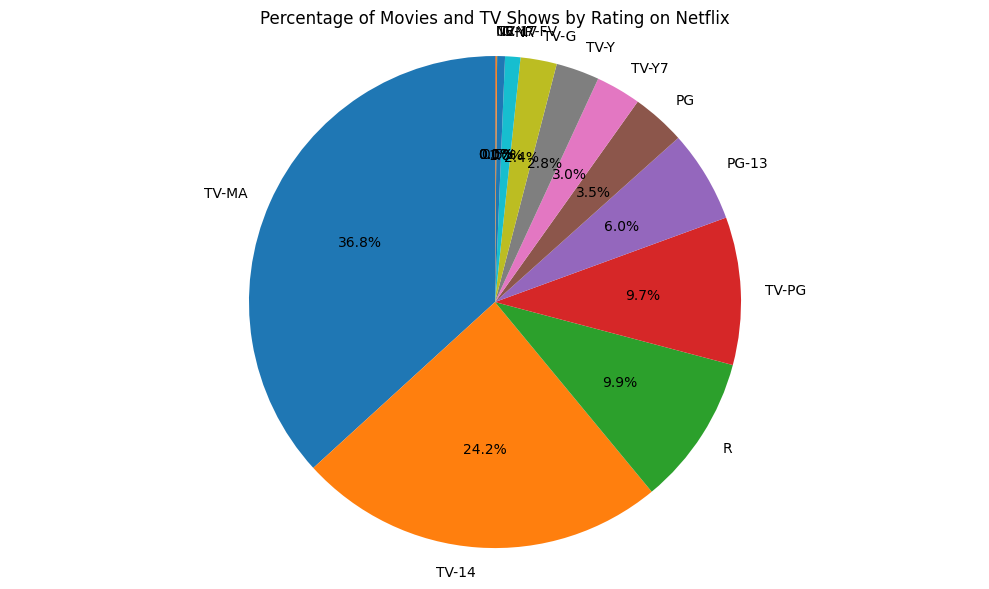

In [12]:
#plotting the pie chart
rating_counts = df['rating'].value_counts()
plt.figure(figsize=(10,6))
plt.pie(rating_counts.values, labels=rating_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Percentage of Movies and TV Shows by Rating on Netflix')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

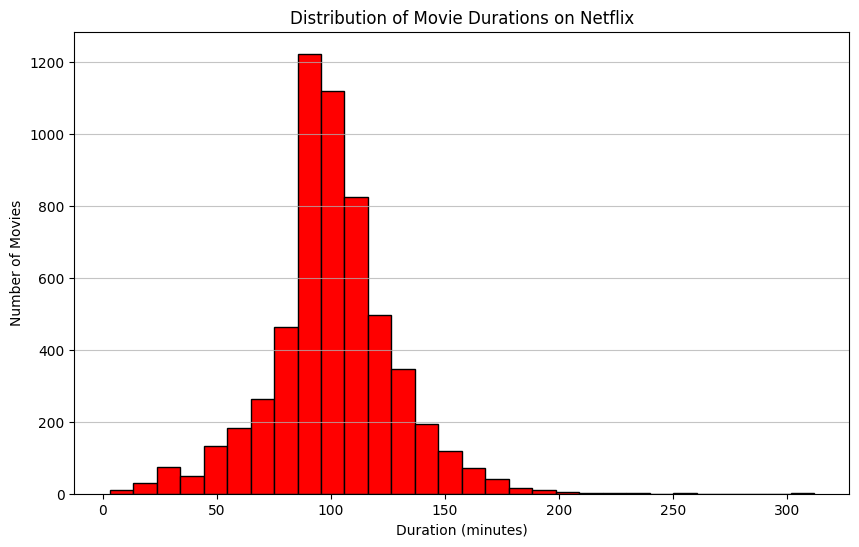

In [ ]:
movie_df = df[df['type'] == 'Movie'].copy()
movie_df['duration'] = movie_df['duration'].str.replace(' min', '').astype(int)

#plotting the histogram
plt.figure(figsize=(10,6))
plt.hist(movie_df['duration'], bins=30, color='red', edgecolor='black')
plt.title('Distribution of Movie Durations on Netflix')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')
plt.grid(axis='y', alpha=0.75)
plt.show()


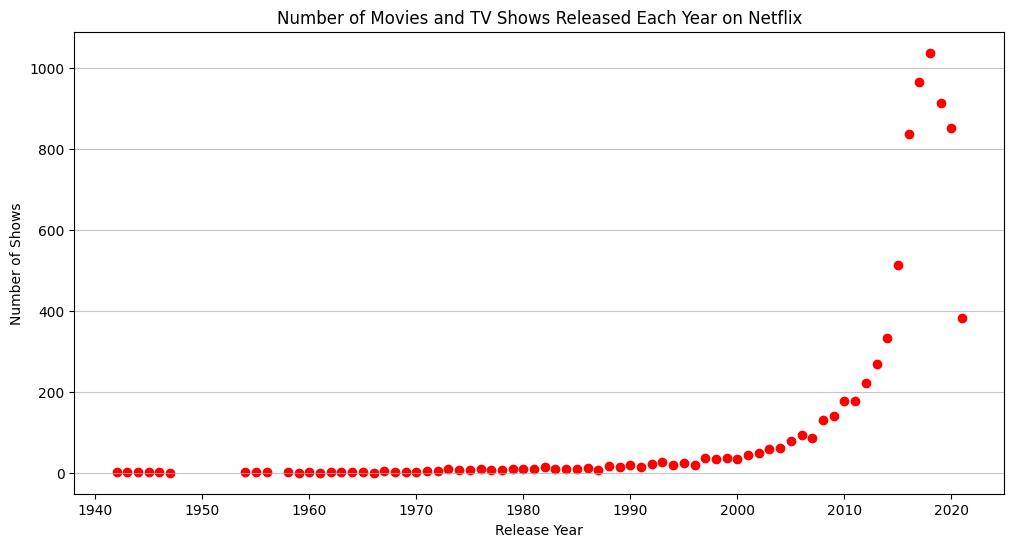

In [17]:
release_counts = df['release_year'].value_counts().sort_index()

#plotting the scatter plot
plt.figure(figsize=(12,6))
plt.scatter(release_counts.index, release_counts.values, color='red')
plt.title('Number of Movies and TV Shows Released Each Year on Netflix')
plt.xlabel('Release Year')
plt.ylabel('Number of Shows')
plt.grid(axis='y', alpha=0.75)
plt.show()

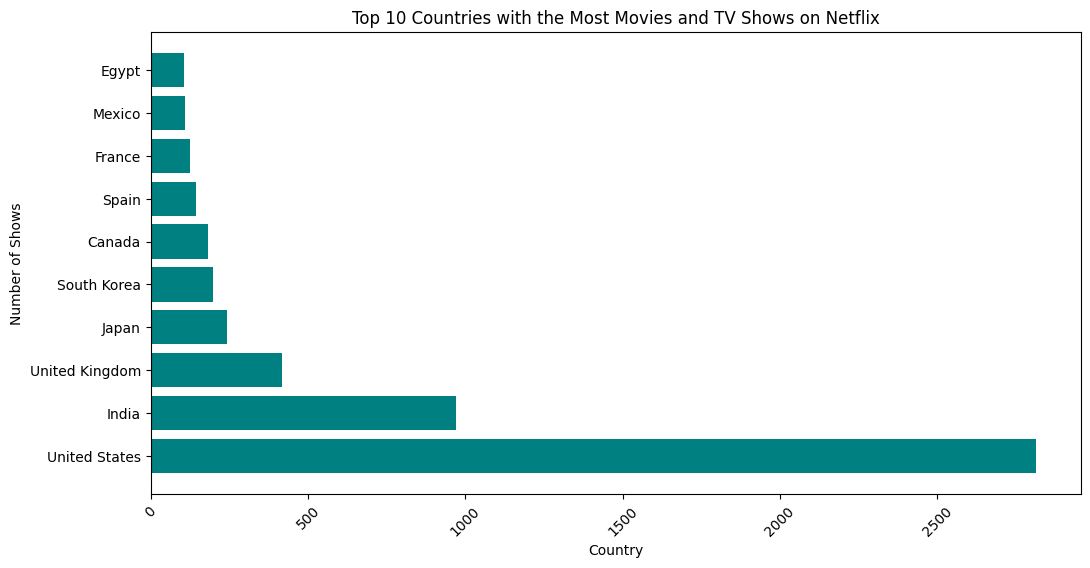

In [18]:
country_counts = df['country'].value_counts().head(10)
##plotting the bar chart for top 10 countries
plt.figure(figsize=(12,6))
plt.barh(country_counts.index, country_counts.values, color='teal')
plt.title('Top 10 Countries with the Most Movies and TV Shows on Netflix')
plt.xlabel('Country')
plt.ylabel('Number of Shows')
plt.xticks(rotation=45)
plt.show()

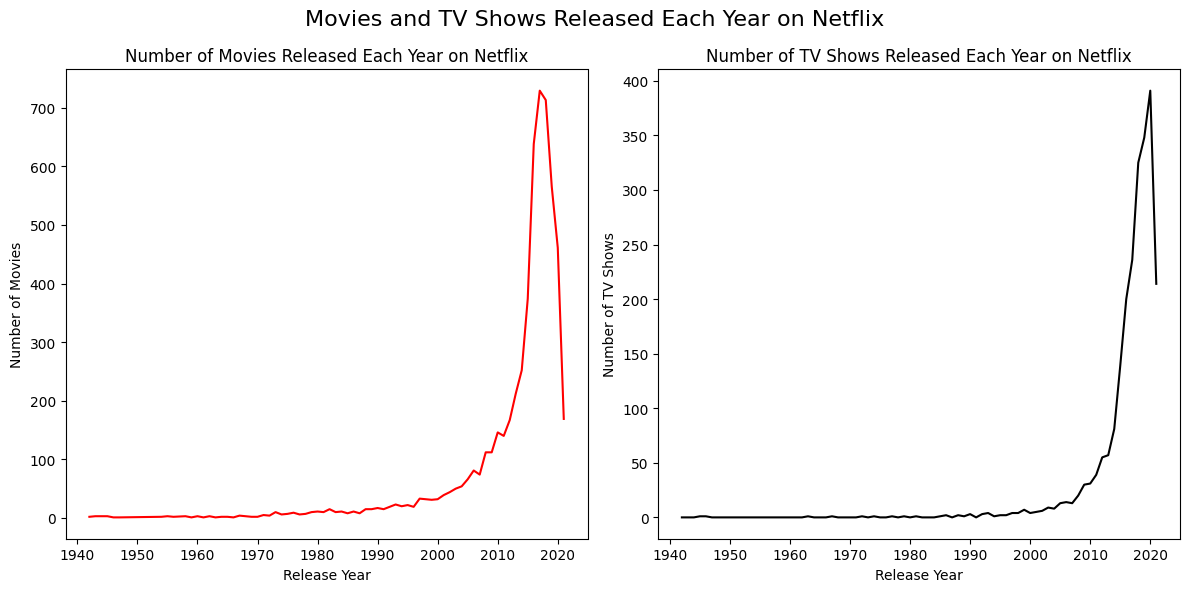

In [ ]:
content_by_year = df.groupby('release_year')['type'].value_counts().unstack().fillna(0)
#plotting the subplots for movies and TV shows released each Year on Netflix
fig, ax = plt.subplots(1,2, figsize=(12,6))
#first subplot for movies
ax[0].plot(content_by_year.index, content_by_year['Movie'], color='red', label='Movies')
ax[0].set_title('Number of Movies Released Each Year on Netflix')
ax[0].set_xlabel('Release Year')
ax[0].set_ylabel('Number of Movies')
#second subplot for TV shows
ax[1].plot(content_by_year.index, content_by_year['TV Show'], color='black', label='TV Shows')
ax[1].set_title('Number of TV Shows Released Each Year on Netflix')
ax[1].set_xlabel('Release Year')
ax[1].set_ylabel('Number of TV Shows')
fig.suptitle('Movies and TV Shows Released Each Year on Netflix', fontsize=16)
plt.tight_layout()
plt.show()